In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import sys

In the following the string graph as exported from cytoscape is read into a undirected graph

In [2]:
# Load the network as an undirected graph
G = nx.read_graphml("../data/graphml_string.graphml").to_undirected()
# relable the nodes with the 'stringdb::canonical name' attribute
G = nx.relabel_nodes(G, nx.get_node_attributes(G, 'stringdb::canonical name'))

In [3]:
#given the two ids "P49790" and "Q9UMS4" generate two ego networks of depth for each of them
ego1 = nx.ego_graph(G, "P49790", radius=1, undirected=True, center=True)
ego2 = nx.ego_graph(G, "Q9UMS4", radius=1, undirected=True, center=True)

#find the common nodes between the two ego networks
common_nodes = set(ego1.nodes()).intersection(set(ego2.nodes()))

print("Common nodes between the two ego networks: ", common_nodes)


Common nodes between the two ego networks:  {'P14678', 'P62318', 'P62316', 'P11142', 'P62314', 'P62304', 'P62306'}


In [4]:
# import the customCircleLayout function from the customCircleLayout.py file
from customCircleLayout import customCircleLayout

customCircleLayout2
['P14635', 'E5RJF8', 'Q8NFH3', 'Q13257', 'Q8TD19', 'P48723', 'P61970', 'Q9UHI6', 'Q9UKF6', 'Q9C0J8', 'O15504', 'Q8N1F7', 'Q96HK7', 'O43301', 'Q9UKX7', 'Q8NFH4', 'Q9H840', 'P46060', 'O14893', 'P35658', '2483', 'Q0VDF9', 'P20700', 'Q92621', 'Q96GD4', 'P54652', 'O95149', 'P78406', 'P49792', 'P55735', 'P41208', 'P11021', 'Q9NPA8', 'Q9BW27', 'Q92973', 'Q7Z3B4', 'P38646', 'Q8WXD5', 'Q9NRG9', 'Q9BZY3', 'Q9UBN7', 'Q15796', 'P34931', 'Q53HL2', 'O75694', 'P61956', 'Q53GS7', 'H0Y8J7', 'Q8NFH5', 'P17066', 'Q12769', 'Q9UBU9', 'P63279', 'Q9BTX1', 'Q10570', 'Q99567', 'Q9UPY3', 'P57740', 'Q69YH5', 'Q13485', 'Q5SRE5', 'P06493', 'Q96EE3', 'Q9Y6J5', 'Q92797', '6409', 'Q13547', 'P11388', 'O95067', 'O14980', 'P84022', 'Q9NWZ8', 'Q14974', 'P63165', 'O60318', 'Q9CZA2', 'Q9UKV8', 'Q53FT3', 'Q9H077', 'P52292', 'P34932', 'Q96F70', 'O95757', 'O95639', 'Q8WUM0', 'Q16630', 'Q8TEQ6', 'O43592', 'O15397', 'Q14493', 'Q9Y6D9', 'Q8TDX7', 'P37198', 'Q9H814', 'H3BLT4', 'P56524', 'Q9P2I0', 'Q5TCJ3', 'Q9

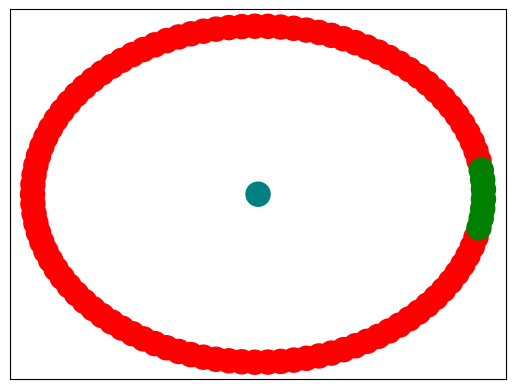

In [5]:
ego1_nodes = [n for n in ego1.nodes() if n not in common_nodes and n != "P49790"]

pos = customCircleLayout(ego1_nodes, list(common_nodes), 0, (0,0), 3)
pos = {**pos, **{'P49790': (0,0)}}
print(pos)
# draw the ego network of "P49790" with the common nodes in the direction of 135 degrees
G_new = nx.Graph()
G_new.add_nodes_from(ego1_nodes, color='red')
G_new.add_nodes_from(common_nodes, color='green')
G_new.add_nodes_from(["P49790"], color='teal')
print(G_new.nodes())
nx.draw_networkx_nodes(G_new, pos, node_color=[G_new.nodes[n]['color'] for n in G_new.nodes()])




customCircleLayout2
['P14635', 'E5RJF8', 'Q8NFH3', 'Q13257', 'Q8TD19', 'P48723', 'P61970', 'Q9UHI6', 'Q9UKF6', 'Q9C0J8', 'O15504', 'Q8N1F7', 'Q96HK7', 'O43301', 'Q9UKX7', 'Q8NFH4', 'Q9H840', 'P46060', 'O14893', 'P35658', '2483', 'Q0VDF9', 'P20700', 'Q92621', 'Q96GD4', 'P54652', 'O95149', 'P78406', 'P49792', 'P55735', 'P41208', 'P11021', 'Q9NPA8', 'Q9BW27', 'Q92973', 'Q7Z3B4', 'P38646', 'Q8WXD5', 'Q9NRG9', 'Q9BZY3', 'Q9UBN7', 'Q15796', 'P34931', 'Q53HL2', 'O75694', 'P61956', 'Q53GS7', 'H0Y8J7', 'Q8NFH5', 'P17066', 'Q12769', 'Q9UBU9', 'P63279', 'Q9BTX1', 'Q10570', 'Q99567', 'Q9UPY3', 'P57740', 'Q69YH5', 'Q13485', 'Q5SRE5', 'P06493', 'Q96EE3', 'Q9Y6J5', 'Q92797', '6409', 'Q13547', 'P11388', 'O95067', 'O14980', 'P84022', 'Q9NWZ8', 'Q14974', 'P63165', 'O60318', 'Q9CZA2', 'Q9UKV8', 'Q53FT3', 'Q9H077', 'P52292', 'P34932', 'Q96F70', 'O95757', 'O95639', 'Q8WUM0', 'Q16630', 'Q8TEQ6', 'O43592', 'O15397', 'Q14493', 'Q9Y6D9', 'Q8TDX7', 'P37198', 'Q9H814', 'H3BLT4', 'P56524', 'Q9P2I0', 'Q5TCJ3', 'Q9

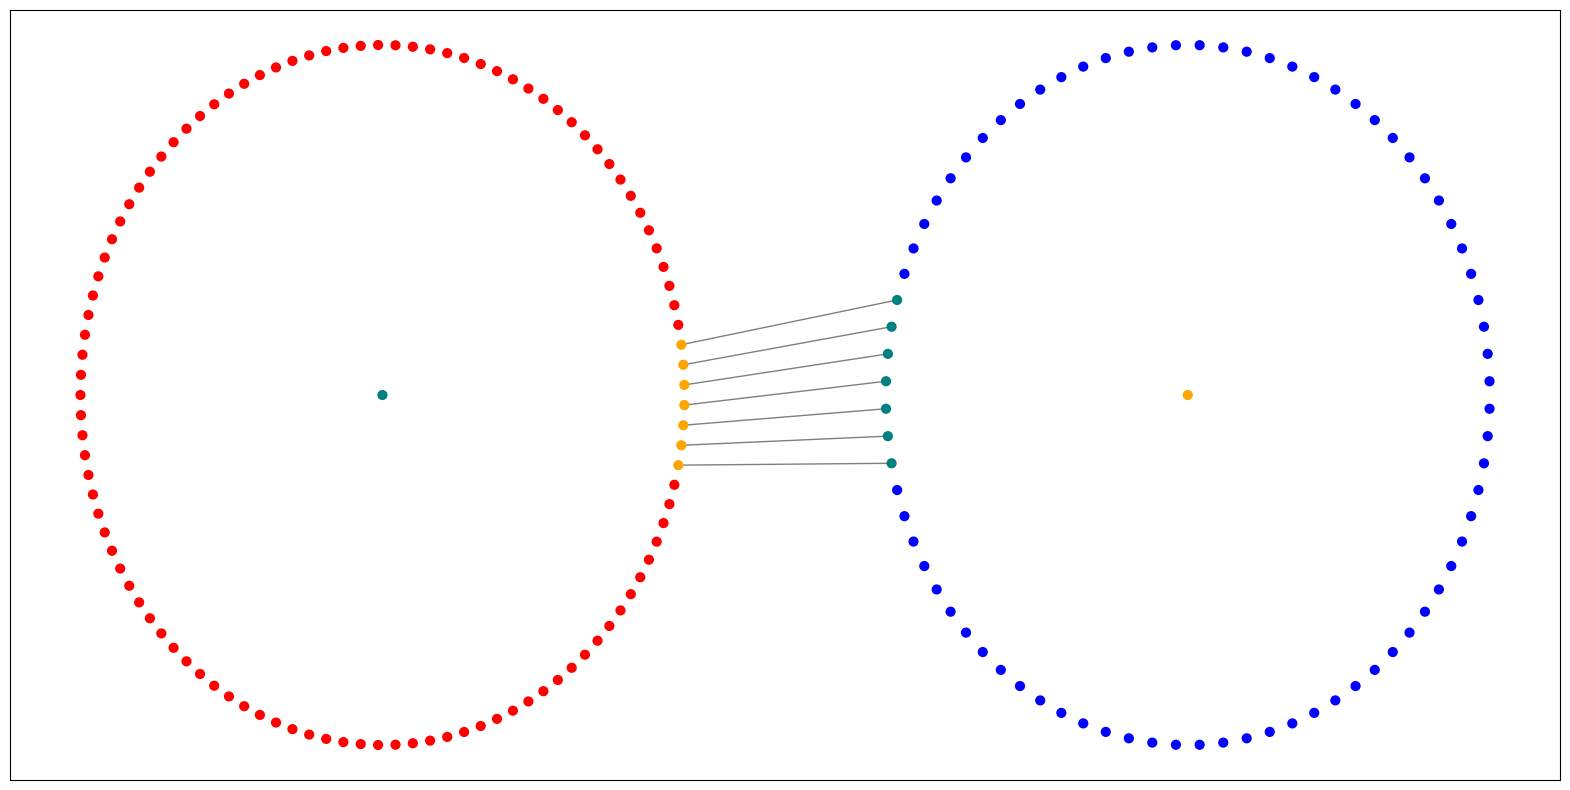

In [6]:
# layout ego1 and ego2 such that the node "P49790" and "Q9UMS4" is in the center and the other nodes are arranged around it in a circle
# the two circles should be arranged in a way that they do not overlap
# the nodes in the two circles should be colored differently
# the shared nodes should be drawen between the two circles

# create a new graph
G_new = nx.Graph()

ego1_nodes = ego1.nodes()
ego2_nodes = ego2.nodes()
#remove the common nodes and the center nodes from the two ego networks

ego1_nodes = [n for n in ego1_nodes if n != "P49790"]
ego2_nodes = [n for n in ego2_nodes if n != "Q9UMS4"]

ego1_notCommon = [n for n in ego1_nodes if n not in common_nodes and n != "P49790"]
ego2_notCommon = [n for n in ego2_nodes if n not in common_nodes and n != "Q9UMS4"]

# duplicate the common nodes in the two ego networks add ego1 and ego2 to the node names
ego1_common_nodes = [n+"_ego1" for n in common_nodes]
ego2_common_nodes = [n+"_ego2" for n in common_nodes]



# add the nodes from the two ego networks
G_new.add_nodes_from(ego1_notCommon, color='red')
G_new.add_nodes_from(ego2_notCommon, color='blue')

G_new.add_nodes_from(["P49790"], color='teal')
G_new.add_nodes_from(["Q9UMS4"], color='orange')

G_new.add_nodes_from(ego1_common_nodes, color='orange')
G_new.add_nodes_from(ego2_common_nodes, color='teal')

#add edges between the duplicated common nodes
for i, n in enumerate(common_nodes):
    G_new.add_edge(n+"_ego1", n+"_ego2")


# set the positions of the nodes
pos1 = customCircleLayout(ego1_notCommon, ego1_common_nodes , 0 ,(2, 2), 1.5, reverse=True)
pos2 = customCircleLayout(ego2_notCommon, ego2_common_nodes, 180 ,(6, 2), 1.5)

# set the positions of the center nodes
pos_center = {"P49790": (2, 2), "Q9UMS4": (6, 2)}

pos = {**pos1, **pos2, **pos_center}
print(pos)
# square figure
plt.figure(figsize=(20,10))

# draw the nodes
nx.draw_networkx_nodes(G_new, pos, node_size=40, node_color=[G_new.nodes[n]['color'] for n in G_new.nodes()])
# draw the edges
nx.draw_networkx_edges(G_new, pos, width=1.0, alpha=0.5)
